In [29]:
from neuralprophet import NeuralProphet
NeuralProphet()

In [30]:
import sys
import os

# Ajouter la racine du projet au PYTHONPATH
sys.path.append(os.path.abspath("../.."))

import pandas as pd
from src.prediction.time_series import train_prophet, forecast_prophet


# Charger le dataset d'exemple
df = pd.read_csv("../../data/examples/urgences_exemple.csv")

# Convertir la colonne datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Vérifier la structure
df.head()

,datetime,arrivals
0,2024-01-01 00:00:00,16.0
1,2024-01-01 01:00:00,15.0
2,2024-01-01 02:00:00,16.0
3,2024-01-01 03:00:00,18.0
4,2024-01-01 04:00:00,15.0


In [34]:
import pandas as pd
from neuralprophet import NeuralProphet

def train_prophet(df: pd.DataFrame, date_col: str, target_col: str):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model

def train_prophet(df, date_col, target_col):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model, model_df

def forecast_prophet(model, df, periods: int, freq: str = "H"):
    future = model.make_future_dataframe(
        df=df,
        periods=periods,
        n_historic_predictions=True
    )
    forecast = model.predict(future)
    return forecast


In [35]:
import inspect
print(inspect.signature(forecast_prophet))



(model, df, periods: int, freq: str = 'H')


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (N

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (34) is too small than the required number                     for the learning rate finder (233). The results might not be optimal.


Finding best initial lr:   0%|          | 0/233 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.954% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1173: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_ts = pd.DataFrame(pd.date_range("1994-01-01", periods=100, freq=freq_str))

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


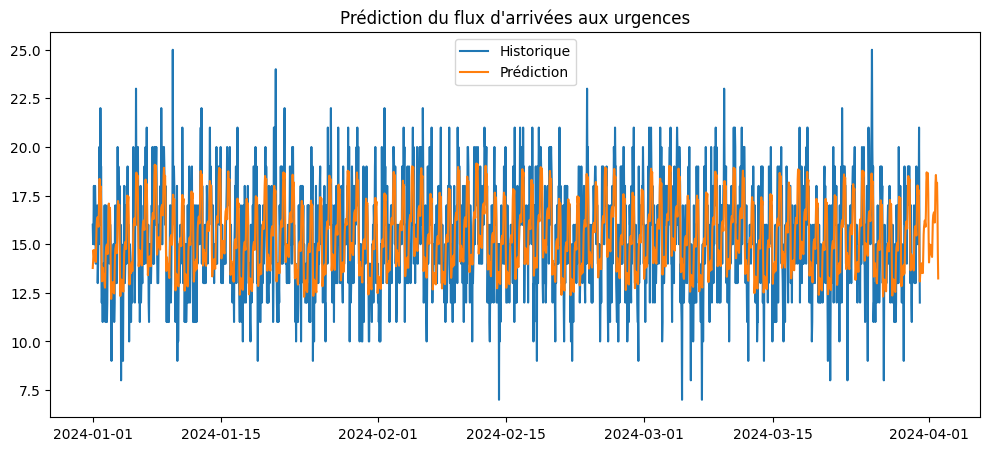

In [36]:
import matplotlib.pyplot as plt

model, model_df = train_prophet(df, "datetime", "arrivals")
forecast = forecast_prophet(model=model, df=model_df, periods=48)
#forecast.head()
#forecast.columns

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["arrivals"], label="Historique")
plt.plot(forecast["ds"], forecast["yhat1"], label="Prédiction")
plt.legend()
plt.title("Prédiction du flux d'arrivées aux urgences")
plt.show()


In [37]:
import numpy as np
import pandas as pd

mu = 20.0  # à ajuster selon ta réalité

# On part de ton forecast existant
mm1 = forecast.copy()
mm1["lambda"] = mm1["yhat1"]          # arrivées prédites par heure
mm1["rho"] = mm1["lambda"] / mu       # taux d'occupation

# On force la stabilité : on ignore (ou marque) les heures où lambda >= mu
mm1["stable"] = mm1["lambda"] < mu

# Formules M/M/1 (là où c'est stable)
mm1.loc[mm1["stable"], "Lq"] = (mm1["rho"]**2 / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "L"]  = (mm1["rho"] / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "Wq"] = mm1["Lq"][mm1["stable"]] / mm1["lambda"][mm1["stable"]]
mm1.loc[mm1["stable"], "W"]  = mm1["L"][mm1["stable"]]  / mm1["lambda"][mm1["stable"]]

In [38]:
mm1["stable"].value_counts()

stable
True    2209
Name: count, dtype: int64

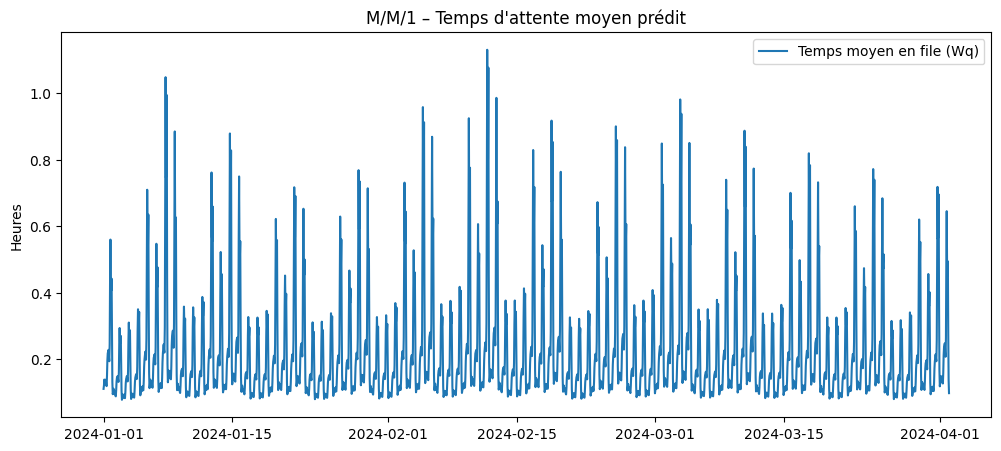

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mm1["ds"], mm1["Wq"], label="Temps moyen en file (Wq)")
plt.ylabel("Heures")
plt.legend()
plt.title("M/M/1 – Temps d'attente moyen prédit")
plt.show()

In [40]:
import numpy as np
import pandas as pd

mu_doc = 3.3  # patients/heure par médecin (estimé)
c_values = [3, 4, 5, 6, 7]  # scénarios de nombre de médecins

lambda_t = forecast["yhat1"].values  # arrivées prédites par heure
ds = forecast["ds"].values

def mmc_metrics(lmbda, mu_doc, c):
    mu_tot = c * mu_doc
    rho = lmbda / mu_tot  # taux d'occupation global

    if lmbda == 0:
        return rho, 0.0  # pas d'arrivées, pas d'attente

    a = lmbda / mu_doc  # charge offerte

    # Calcul de P0 (probabilité que le système soit vide)
    sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))
    last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

    if rho >= 1:
        return rho, np.inf  # système instable

    P0 = 1.0 / (sum_terms + last_term)

    # Probabilité qu'un patient attende (Erlang C)
    Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

    # Temps moyen en file (Wq)
    Wq = Pc / (c * mu_doc - lmbda)  # en heures

    return rho, Wq

# On construit un DataFrame avec un Wq par scénario de c
mmc = pd.DataFrame({"ds": ds, "lambda": lambda_t})

for c in c_values:
    rhos = []
    wqs = []
    for lmbda in lambda_t:
        rho, Wq = mmc_metrics(lmbda, mu_doc, c)
        rhos.append(rho)
        wqs.append(Wq)
    mmc[f"rho_c{c}"] = rhos
    mmc[f"Wq_c{c}"] = wqs


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else n

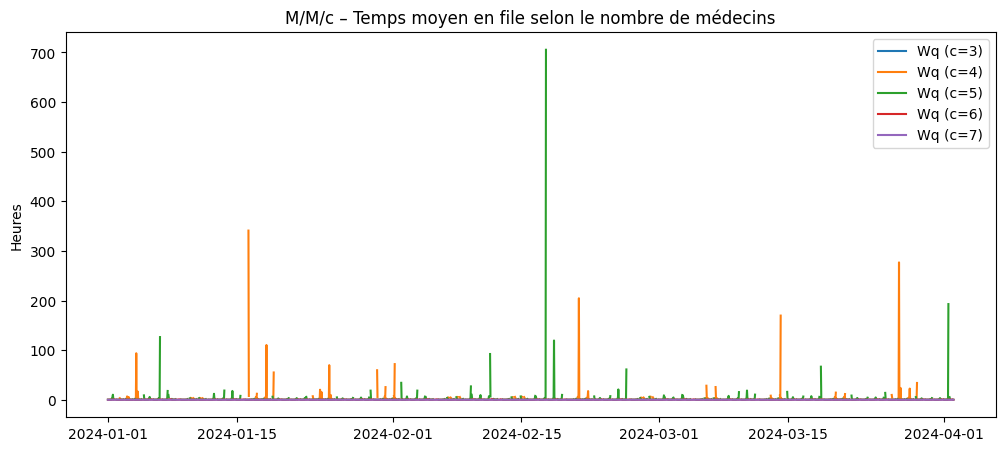

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for c in c_values:
    plt.plot(mmc["ds"], mmc[f"Wq_c{c}"], label=f"Wq (c={c})")
plt.ylabel("Heures")
plt.title("M/M/c – Temps moyen en file selon le nombre de médecins")
plt.legend()
plt.show()

In [42]:
Wq_target = 0.5  # 30 minutes

results = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    # proportion d'heures où le temps d'attente est sous le seuil
    pct_ok = (Wq < Wq_target).mean() * 100
    results.append((c, pct_ok))

results


[(3, 0.0),
 (4, 0.0),
 (5, 46.220009053870534),
 (6, 92.16840199185151),
 (7, 100.0)]

In [43]:
optimal = None
for c, pct in results:
    if pct >= 95:   # objectif : 95% des heures sous 30 minutes
        optimal = c
        break

optimal

7

In [44]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["Médecins (c)", "% heures Wq < 30 min"])
df_results

,Médecins (c),% heures Wq < 30 min
0,3,0.000000
1,4,0.000000
2,5,46.220009
3,6,92.168402
4,7,100.000000


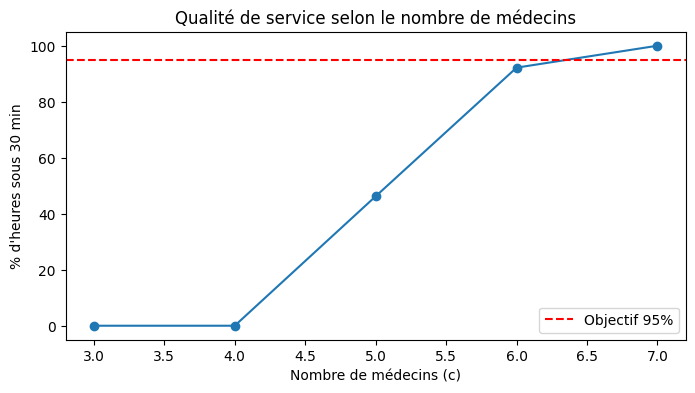

In [45]:
plt.figure(figsize=(8,4))
plt.plot(df_results["Médecins (c)"], df_results["% heures Wq < 30 min"], marker="o")
plt.axhline(95, color="red", linestyle="--", label="Objectif 95%")
plt.ylabel("% d'heures sous 30 min")
plt.xlabel("Nombre de médecins (c)")
plt.title("Qualité de service selon le nombre de médecins")
plt.legend()
plt.show()

In [46]:
Wq_target = 0.25  # 15 minutes

results_15 = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    pct_ok = (Wq < Wq_target).mean() * 100
    results_15.append((c, pct_ok))

results_15

[(3, 0.0),
 (4, 0.0),
 (5, 25.305568130375732),
 (6, 81.80172023540064),
 (7, 100.0)]

In [47]:
optimal_15 = None
for c, pct in results_15:
    if pct >= 95:   # objectif : 95% des heures sous 15 minutes
        optimal_15 = c
        break

optimal_15


7

In [48]:
def optimal_c_per_hour(lambda_t, mu_doc, Wq_target=0.5, c_max=12):
    for c in range(1, c_max+1):
        rho, Wq = mmc_metrics(lambda_t, mu_doc, c)
        if Wq < Wq_target:
            return c
    return c_max  # si jamais aucun c ne suffit

mmc["c_opt_30min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.5)
    for lmbda in mmc["lambda"]
]

mmc["c_opt_15min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.25)
    for lmbda in mmc["lambda"]
]

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARN

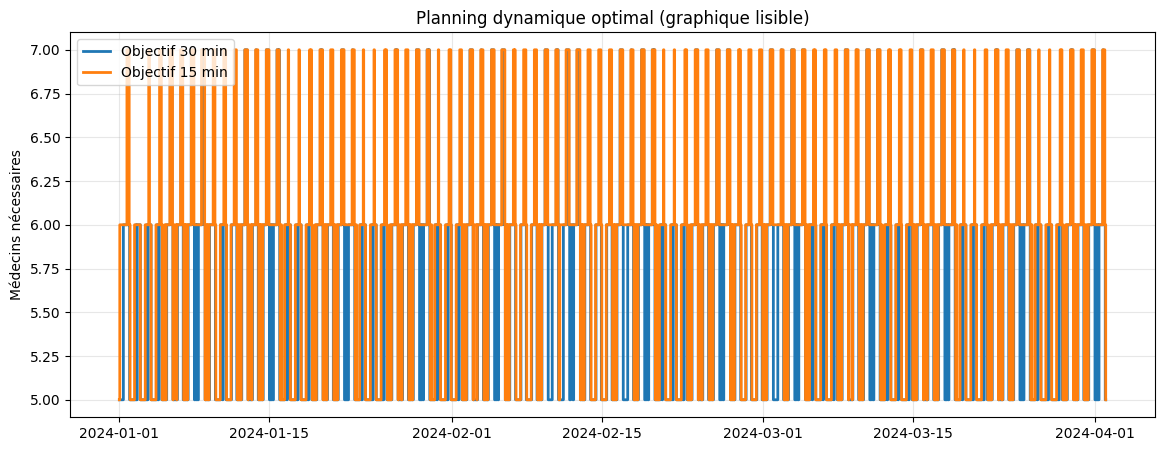

In [50]:
#plt.figure(figsize=(12,5))
#plt.plot(mmc["ds"], mmc["c_opt_30min"], label="Objectif 30 min")
#plt.plot(mmc["ds"], mmc["c_opt_15min"], label="Objectif 15 min")
#plt.ylabel("Médecins nécessaires")
#plt.title("Planning dynamique optimal")
#plt.legend()
#plt.show()

plt.figure(figsize=(14, 5))

plt.step(mmc["ds"], mmc["c_opt_30min"], where="post", label="Objectif 30 min", linewidth=2)
plt.step(mmc["ds"], mmc["c_opt_15min"], where="post", label="Objectif 15 min", linewidth=2)

plt.ylabel("Médecins nécessaires")
plt.title("Planning dynamique optimal (graphique lisible)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [51]:
import pandas as pd

def compress_schedule(times, values):
    """
    Regroupe les périodes consécutives où la valeur reste identique.
    """
    segments = []
    start = times[0]
    current_value = values[0]

    for i in range(1, len(times)):
        if values[i] != current_value:
            segments.append((start, times[i-1], current_value))
            start = times[i]
            current_value = values[i]

    # dernier segment
    segments.append((start, times.iloc[-1], current_value))
    return segments

# Création des segments pour les deux objectifs
segments_30 = compress_schedule(mmc["ds"], mmc["c_opt_30min"])
segments_15 = compress_schedule(mmc["ds"], mmc["c_opt_15min"])

# Fusion des deux plannings
rows = []
for (s30, e30, v30), (_, _, v15) in zip(segments_30, segments_15):
    rows.append({
        "Début": s30,
        "Fin": e30,
        "Médecins (30 min)": v30,
        "Médecins (15 min)": v15
    })

planning_df = pd.DataFrame(rows)
planning_df


,Début,Fin,Médecins (30 min),Médecins (15 min)
0,2024-01-01 00:00:00,2024-01-01 08:00:00,5,5
1,2024-01-01 09:00:00,2024-01-01 17:00:00,6,6
2,2024-01-01 18:00:00,2024-01-01 18:00:00,7,7
3,2024-01-01 19:00:00,2024-01-01 22:00:00,6,6
4,2024-01-01 23:00:00,2024-01-02 12:00:00,5,5
...,...,...,...,...
398,2024-04-01 07:00:00,2024-04-01 08:00:00,5,7
399,2024-04-01 09:00:00,2024-04-01 17:00:00,6,6
400,2024-04-01 18:00:00,2024-04-01 18:00:00,7,7
401,2024-04-01 19:00:00,2024-04-01 22:00:00,6,6


In [52]:
# Résumé par jour
daily_summary = mmc.groupby(mmc["ds"].dt.date).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

daily_summary.columns = ["Date", "Médecins (30 min)", "Médecins (15 min)"]
daily_summary

,Date,Médecins (30 min),Médecins (15 min)
0,2024-01-01,7,7
1,2024-01-02,6,6
2,2024-01-03,6,7
3,2024-01-04,6,7
4,2024-01-05,7,7
...,...,...,...
88,2024-03-29,7,7
89,2024-03-30,6,7
90,2024-03-31,7,7
91,2024-04-01,7,7


In [53]:
mmc["week"] = mmc["ds"].dt.isocalendar().week

weekly_summary = mmc.groupby("week").agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

weekly_summary.columns = ["Semaine", "Médecins (30 min)", "Médecins (15 min)"]
weekly_summary


,Semaine,Médecins (30 min),Médecins (15 min)
0,1,7,7
1,2,7,7
2,3,7,7
3,4,7,7
4,5,7,7
5,6,7,7
6,7,7,7
7,8,7,7
8,9,7,7
9,10,7,7


In [54]:
def zone_color(c):
    if c <= 5:
        return "🟢 Creuse"
    elif c == 6:
        return "🟡 Normale"
    else:
        return "🔴 Pointe"

daily_summary["Zone (30 min)"] = daily_summary["Médecins (30 min)"].apply(zone_color)
daily_summary["Zone (15 min)"] = daily_summary["Médecins (15 min)"].apply(zone_color)

daily_summary


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe
1,2024-01-02,6,6,🟡 Normale,🟡 Normale
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe
...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe


In [57]:
cost_doc = 80
cost_wait = 20

def total_cost(lmbda, mu_doc, c):
    rho, Wq = mmc_metrics(lmbda, mu_doc, c)
    return c * cost_doc + lmbda * Wq * cost_wait

mmc["cost_30min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_30min"])
]

mmc["cost_15min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_15min"])
]

daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_21564\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0



,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,12805.534511,12698.763175
1,2024-01-02,11837.619064,11737.899262
2,2024-01-03,11719.549821,11655.985829
3,2024-01-04,11901.721063,11849.262880
4,2024-01-05,12491.939179,12467.322493
...,...,...,...
88,2024-03-29,12475.735505,12359.040625
89,2024-03-30,12498.736092,12470.286940
90,2024-03-31,12485.791602,12461.248000
91,2024-04-01,13079.880230,12828.473080


In [58]:
daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,12805.534511,12698.763175
1,2024-01-02,11837.619064,11737.899262
2,2024-01-03,11719.549821,11655.985829
3,2024-01-04,11901.721063,11849.262880
4,2024-01-05,12491.939179,12467.322493
...,...,...,...
88,2024-03-29,12475.735505,12359.040625
89,2024-03-30,12498.736092,12470.286940
90,2024-03-31,12485.791602,12461.248000
91,2024-04-01,13079.880230,12828.473080
